<a href="https://colab.research.google.com/github/mrunalkavade/Deep-Learning-Based-COVID-19-Classification-Using-Chest-Radiography-Images/blob/main/AgenticAi_Resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/DL/COVID-19_Radiography_Dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted Successfully")

Mounted at /content/drive
Extracted Successfully


In [ ]:
dataset_path = "/content/dataset/COVID-19_Radiography_Dataset"

In [ ]:
import shutil
import random

if os.path.exists("/content/data_split"):
    shutil.rmtree("/content/data_split")

base_dir = "/content/data_split"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir)
os.makedirs(val_dir)
os.makedirs(test_dir)

classes = [cls for cls in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, cls))]

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    image_folder = cls_path # Corrected: Removed "images" subfolder

    images = [img for img in os.listdir(image_folder)
              if img.endswith(('.png', '.jpg', '.jpeg'))]

    random.shuffle(images)

    train_split = int(0.7 * len(images))
    val_split = int(0.85 * len(images))

    splits = {
        train_dir: images[:train_split],
        val_dir: images[train_split:val_split],
        test_dir: images[val_split:]
    }

    for folder, split_imgs in splits.items():
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

        for img in split_imgs:
            shutil.copy(os.path.join(image_folder, img),
                        os.path.join(folder, cls, img))

print("Data Split Done")

Data Split Done


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 14814 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=64,              # 🔥 was 32 → 64 (fewer batches)
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical'
)

Found 14814 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,              # stop early → saves time
    restore_best_weights=True
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,     # ↓ from 30
    zoom_range=0.1,        # ↓ from 0.3
    horizontal_flip=True
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.7100 - loss: 0.8172 - val_accuracy: 0.8438 - val_loss: 0.4397
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.8100 - loss: 0.5456 - val_accuracy: 0.8630 - val_loss: 0.3775
Epoch 3/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 230s 990ms/step - accuracy: 0.8303 - loss: 0.4801 - val_accuracy: 0.8753 - val_loss: 0.3482
Epoch 4/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 263s 993ms/step - accuracy: 0.8422 - loss: 0.4401 - val_accuracy: 0.8775 - val_loss: 0.3331
Epoch 5/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 231s 995ms/step - accuracy: 0.8520 - loss: 0.4133 - val_accuracy: 0.8835 - val_loss: 0.3174
Epoch 6/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 228s 981ms/step - accuracy: 0.8586 - loss: 0.3871 - val_accuracy: 0.8841 - val_loss: 0.3101
Epoch 7/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 226s 974ms/step - accuracy: 0.8695 - loss: 0.3636 - val_accuracy: 0.8907 - val_loss: 0.2915
Epoch 8/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 228s 984ms/step - accuracy: 0.8716 - loss:

In [ ]:
# Final accuracies
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

Final Training Accuracy: 0.8786958456039429
Final Validation Accuracy: 0.8985826969146729


In [ ]:
loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - accuracy: 0.8885 - loss: 0.3131
Test Accuracy: 0.8885390162467957


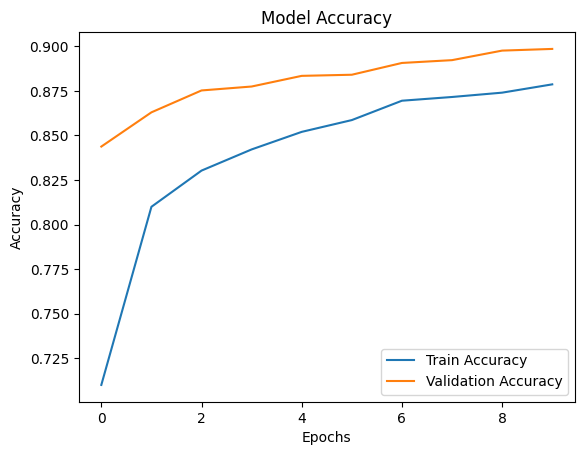

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

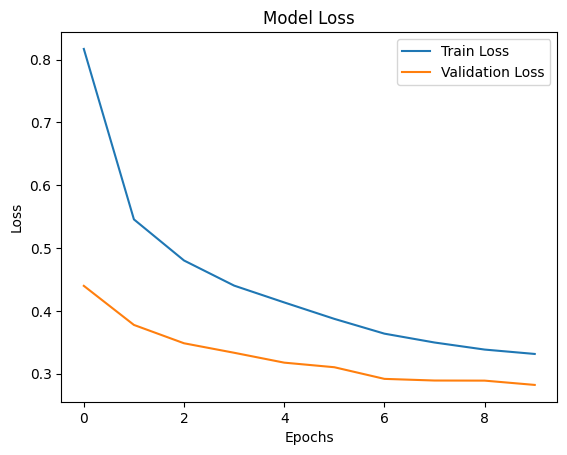

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
import numpy as np

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step


In [ ]:
y_true = test_generator.classes

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

[[ 436   35   69    3]
 [  15  733  154    0]
 [  12   37 1478    2]
 [   1    1   25  175]]


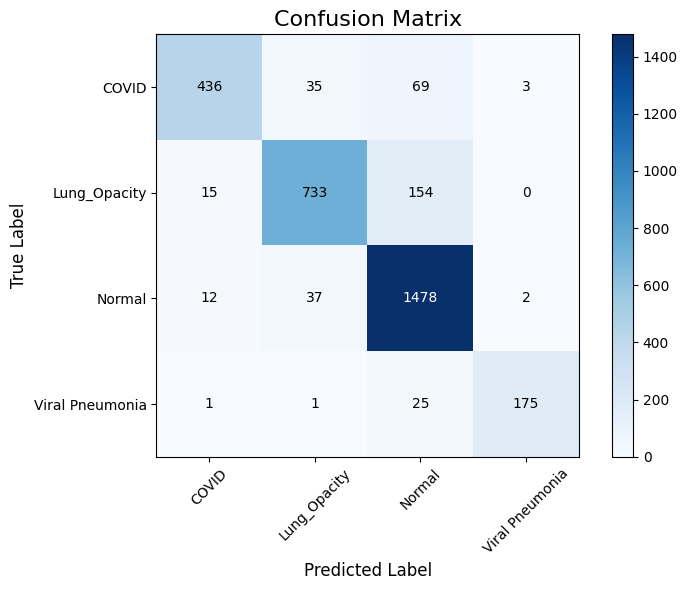

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Plot with blue color map
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

plt.title("Confusion Matrix", fontsize=16)
plt.colorbar()

class_names = list(test_generator.class_indices.keys())

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, fontsize=10)
plt.yticks(tick_marks, class_names, fontsize=10)

# Add numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

                 precision    recall  f1-score   support

          COVID       0.94      0.80      0.87       543
   Lung_Opacity       0.91      0.81      0.86       902
         Normal       0.86      0.97      0.91      1529
Viral Pneumonia       0.97      0.87      0.92       202

       accuracy                           0.89      3176
      macro avg       0.92      0.86      0.89      3176
   weighted avg       0.89      0.89      0.89      3176



**********************************

GRAD-CAM

In [ ]:
!pip install opencv-python matplotlib

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model

In [ ]:
last_conv_layer_name = "conv5_block3_out"  # for ResNet50

In [ ]:
for layer in model.layers:
    print(layer.name)

input_layer
conv1_pad
conv1_conv
conv1_bn
conv1_relu
pool1_pad
pool1_pool
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_2_bn
conv2_block1_2_relu
conv2_block1_0_conv
conv2_block1_3_conv
conv2_block1_0_bn
conv2_block1_3_bn
conv2_block1_add
conv2_block1_out
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_2_bn
conv2_block2_2_relu
conv2_block2_3_conv
conv2_block2_3_bn
conv2_block2_add
conv2_block2_out
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_2_bn
conv2_block3_2_relu
conv2_block3_3_conv
conv2_block3_3_bn
conv2_block3_add
conv2_block3_out
conv3_block1_1_conv
conv3_block1_1_bn
conv3_block1_1_relu
conv3_block1_2_conv
conv3_block1_2_bn
conv3_block1_2_relu
conv3_block1_0_conv
conv3_block1_3_conv
conv3_block1_0_bn
conv3_block1_3_bn
conv3_block1_add
conv3_block1_out
conv3_block2_1_conv
conv3_block2_1_bn
conv3_block2_1_relu
conv3_block2_2_conv
conv3_block2_2_bn
co

In [ ]:
def get_gradcam_heatmap(model, image, last_conv_layer_name, pred_index=None):

    grad_model = Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def superimpose_heatmap(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img

    return np.uint8(superimposed_img)

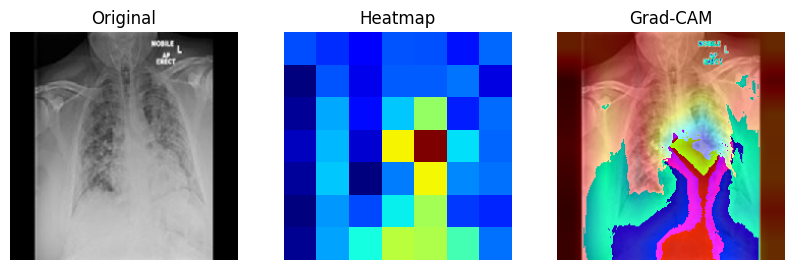

In [ ]:
import os

covid_images_dir = os.path.join(dataset_path, "COVID")

# Find the first image file in the COVID directory
img_filename = None
for f in os.listdir(covid_images_dir):
    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_filename = f
        break

if img_filename is None:
    raise FileNotFoundError(f"No image files found in {covid_images_dir}")

img_path = os.path.join(covid_images_dir, img_filename)

# Preprocess image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Generate heatmap
heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)

# Overlay
superimposed_img = superimpose_heatmap(img_path, heatmap)

# Show results
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Grad-CAM")
plt.imshow(superimposed_img)
plt.axis("off")

plt.show()

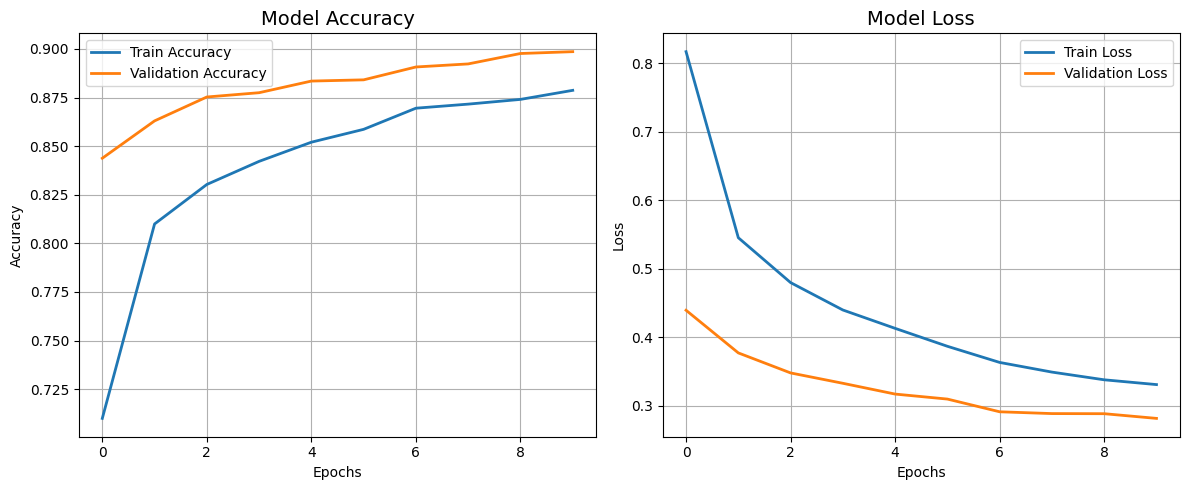

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have: history = model.fit(...)

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

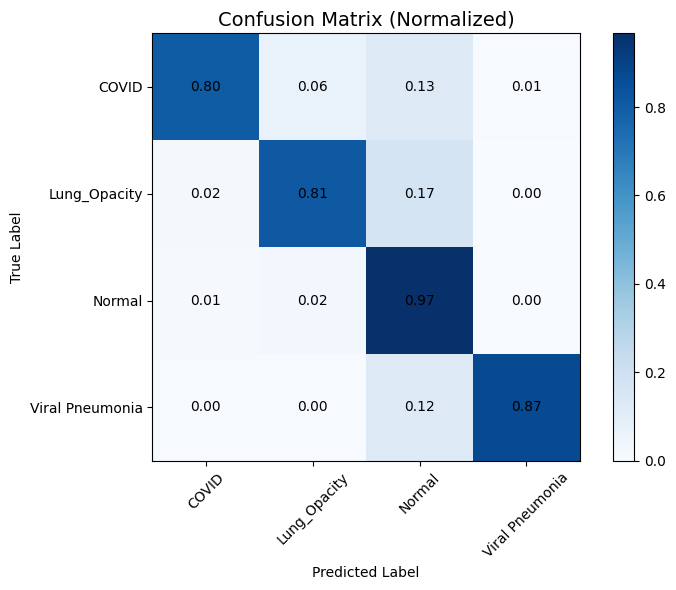

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

# Normalize (optional)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Normalized)", fontsize=14)
plt.colorbar()

class_names = list(test_generator.class_indices.keys())

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

# Add values inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm_normalized[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

Classification Report:

                 precision    recall  f1-score   support

          COVID       0.94      0.80      0.87       543
   Lung_Opacity       0.91      0.81      0.86       902
         Normal       0.86      0.97      0.91      1529
Viral Pneumonia       0.97      0.87      0.92       202

       accuracy                           0.89      3176
      macro avg       0.92      0.86      0.89      3176
   weighted avg       0.89      0.89      0.89      3176



In [ ]:
import tensorflow as tf
import cv2
import numpy as np

def get_gradcam_heatmap(model, image, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def overlay_heatmap(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img

    return np.uint8(superimposed_img)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


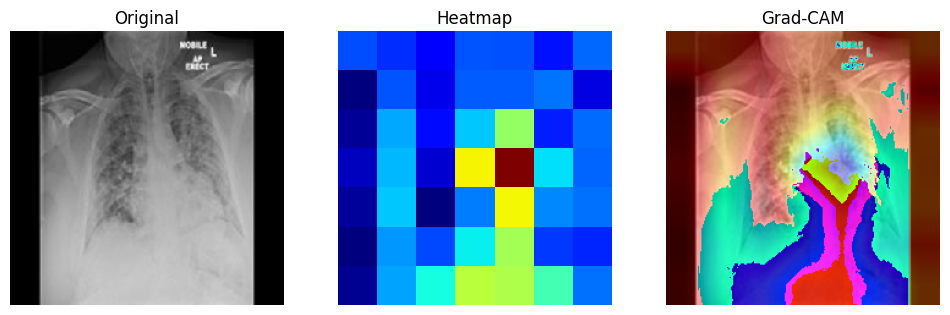

In [ ]:
import matplotlib.pyplot as plt
import os

# Using a known existing image from the COVID class
img_path = os.path.join(dataset_path, "COVID", "COVID-218.png")

# Preprocess
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Last conv layer (ResNet50)
last_conv_layer_name = "conv5_block3_out"

# Generate heatmap
heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)

# Overlay
gradcam_img = overlay_heatmap(img_path, heatmap)

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Grad-CAM")
plt.imshow(gradcam_img)
plt.axis('off')

plt.show()